In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("../DataEnedis10_000/enedis_region_data.csv")

In [7]:
# Удалим строки без consommation
df = df[df['conso_totale_mwh'].notna()]

# Убедимся, что consommation — числовая
df['conso_totale_mwh'] = pd.to_numeric(df['conso_totale_mwh'], errors='coerce')

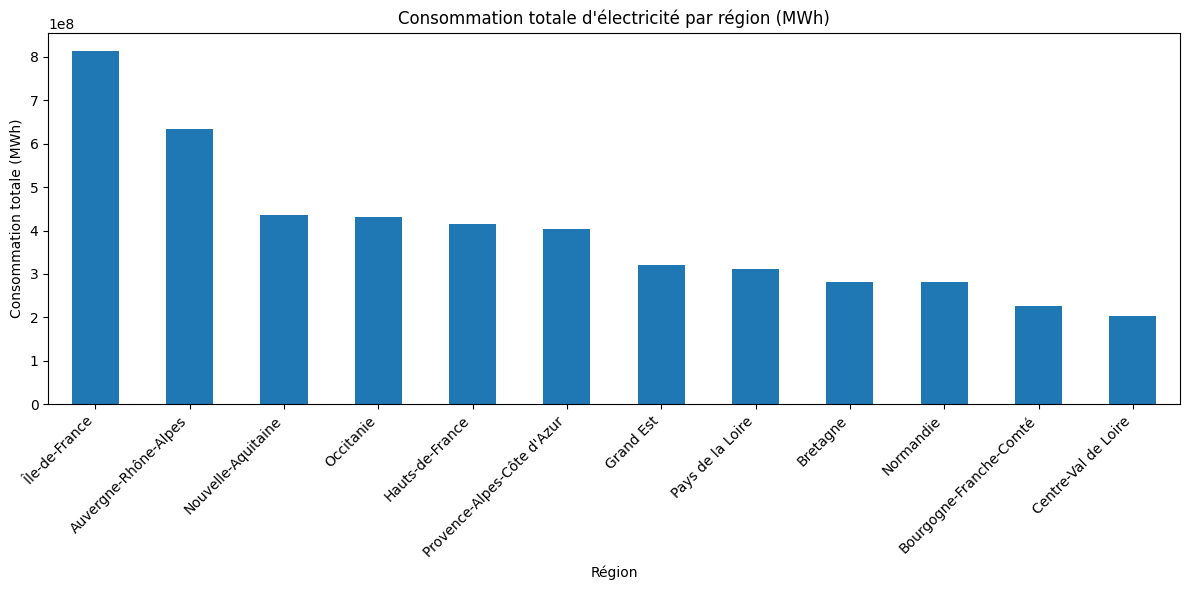

In [8]:
# === 1. Consommation totale par région ===
region_total = df.groupby('nom_region')['conso_totale_mwh'].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
region_total.plot(kind='bar')
plt.title("Consommation totale d'électricité par région (MWh)")
plt.xlabel("Région")
plt.ylabel("Consommation totale (MWh)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

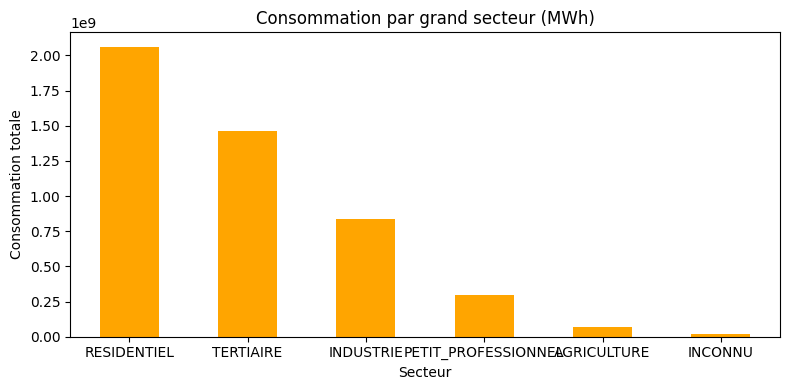

In [9]:
# === 2. Consommation par secteur ===
secteur_total = df.groupby('code_grand_secteur')['conso_totale_mwh'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,4))
secteur_total.plot(kind='bar', color='orange')
plt.title("Consommation par grand secteur (MWh)")
plt.xlabel("Secteur")
plt.ylabel("Consommation totale")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

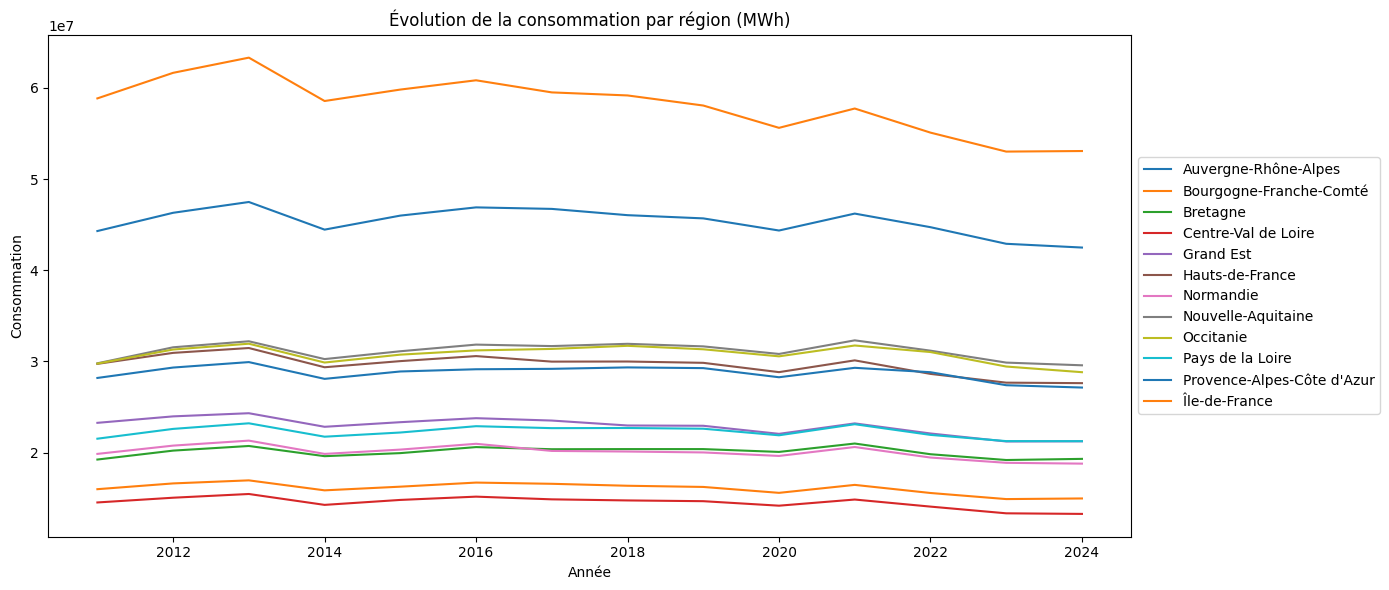

In [10]:
# === 3. Evolution temporelle par région ===
pivot = df.pivot_table(values='conso_totale_mwh', index='annee', columns='nom_region', aggfunc='sum')
pivot.plot(figsize=(14,6))
plt.title("Évolution de la consommation par région (MWh)")
plt.xlabel("Année")
plt.ylabel("Consommation")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

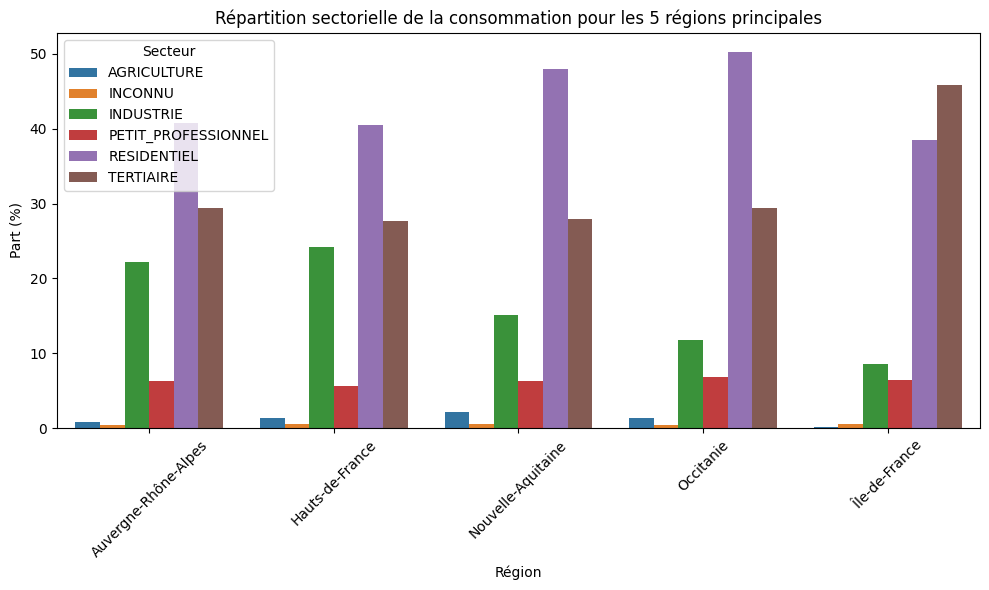

In [12]:
# === 4. Répartition des secteurs par région (pourcentage) ===
secteurs_region = df.groupby(['nom_region', 'code_grand_secteur'])['conso_totale_mwh'].sum().reset_index()

# Total par région
total_par_region = secteurs_region.groupby('nom_region')['conso_totale_mwh'].transform('sum')
secteurs_region['pourcentage'] = (secteurs_region['conso_totale_mwh'] / total_par_region) * 100

# Exemple : afficher топ 5 régions с долями секторов
top5 = secteurs_region[secteurs_region['nom_region'].isin(region_total.head(5).index)]

import seaborn as sns
plt.figure(figsize=(10,6))
sns.barplot(data=top5, x='nom_region', y='pourcentage', hue='code_grand_secteur')
plt.title("Répartition sectorielle de la consommation pour les 5 régions principales")
plt.ylabel("Part (%)")
plt.xlabel("Région")
plt.xticks(rotation=45)
plt.legend(title="Secteur")
plt.tight_layout()
plt.show()